# **Major Project : Indian Pre-Owned Car Price Prediction**

## **Component 1A: Machine Learning Regression**

## Introduction

The pre-owned car market contains a large number of vehicles with
different brands, models, ages, mileage, engine specifications and
other features. These factors can affect the resale price of a car.

In this project, machine learning techniques are used to analyze
historical pre-owned car data and predict the price of a car based
on its characteristics.

The project includes data exploration, preprocessing, feature
engineering, regression model building, model evaluation and
prediction.

## Objective

The main objective of this project is to develop a machine learning
regression model that can predict the price of pre-owned cars using
their available features.

The project aims to:

- Analyze and understand the given dataset.
- Perform proper exploratory data analysis.
- Handle missing values and data quality issues.
- Perform suitable feature engineering and preprocessing.
- Build and compare different regression models.
- Tune the selected models using cross-validation.
- Evaluate the models using RMSE, MAE and R².
- Use the best model to predict prices for the unseen test data.

In [ ]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load the training dataset

train_df = pd.read_csv("/content/Cap_Training_Data_2025.csv")

In [ ]:
# Dataset Overview

print("Number of rows:", train_df.shape[0])
print("Number of columns:", train_df.shape[1])

Number of rows: 53515
Number of columns: 17


In [ ]:
# Displaying First 5 records

train_df.head()

,ID,Maker,model,Location,Distance,Owner Type,manufacture_year,Age of car,engine_displacement,engine_power,body_type,Vroom Audit Rating,transmission,door_count,seat_count,fuel_type,Price
0,11100001,skoda,octavia,Ahmedabad,NaN,Second,1973.0,52,1964,147.0,compact,8,man,NaN,NaN,petrol,543764.25
1,11100002,fiat,panda,Ahmedabad,27750.0,Third,2021.0,4,1242,51.0,NaN,6,man,4.0,4.0,petrol,401819.25
2,11100003,bmw,x1,Hyderabad,46000.0,Third,2023.0,2,1995,105.0,NaN,7,auto,4.0,5.0,diesel,2392855.50
3,11100004,nissan,juke,Mumbai,43949.0,Third,2020.0,5,1618,140.0,NaN,7,man,4.0,5.0,petrol,958606.50
4,11100005,bmw,x5,Jaipur,59524.0,Fourth & Above,2021.0,4,2993,180.0,NaN,7,auto,4.0,5.0,diesel,3085561.50


In [ ]:
# Displaying last 5 records

train_df.tail()

,ID,Maker,model,Location,Distance,Owner Type,manufacture_year,Age of car,engine_displacement,engine_power,body_type,Vroom Audit Rating,transmission,door_count,seat_count,fuel_type,Price
53510,11153511,skoda,octavia,Delhi,29334.0,Fourth & Above,2023.0,2,1598,77.0,NaN,4,man,4.0,5.0,diesel,1342996.50
53511,11153512,skoda,octavia,Bangalore,223631.0,Fourth & Above,2018.0,7,1900,77.0,NaN,8,man,5.0,5.0,diesel,510732.75
53512,11153513,bmw,x1,Pune,25500.0,Third,2024.0,1,1995,105.0,NaN,4,auto,4.0,5.0,diesel,2008123.50
53513,11153514,toyota,avensis,Jaipur,1195500.0,Third,2020.0,5,11950,93.0,compact,5,man,NaN,NaN,diesel,874352.25
53514,11153515,bmw,x5,Kochi,142000.0,First,2017.0,8,2993,173.0,NaN,4,auto,5.0,5.0,diesel,1576610.25


In [ ]:
# Check column names

train_df.columns

Index(['ID', 'Maker', 'model', 'Location', 'Distance ', 'Owner Type',
       'manufacture_year', 'Age of car', 'engine_displacement', 'engine_power',
       'body_type', 'Vroom Audit Rating', 'transmission', 'door_count',
       'seat_count', 'fuel_type', 'Price'],
      dtype='object')

In [ ]:
# Cleaning column names

train_df.columns = train_df.columns.str.strip()
train_df.columns

Index(['ID', 'Maker', 'model', 'Location', 'Distance', 'Owner Type',
       'manufacture_year', 'Age of car', 'engine_displacement', 'engine_power',
       'body_type', 'Vroom Audit Rating', 'transmission', 'door_count',
       'seat_count', 'fuel_type', 'Price'],
      dtype='object')

In [ ]:
# Dataset information

train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53515 entries, 0 to 53514
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   53515 non-null  int64  
 1   Maker                53515 non-null  object 
 2   model                53515 non-null  object 
 3   Location             53509 non-null  object 
 4   Distance             52304 non-null  float64
 5   Owner Type           53515 non-null  object 
 6   manufacture_year     53513 non-null  float64
 7   Age of car           53515 non-null  int64  
 8   engine_displacement  53515 non-null  int64  
 9   engine_power         52076 non-null  float64
 10  body_type            4136 non-null   object 
 11  Vroom Audit Rating   53515 non-null  int64  
 12  transmission         53515 non-null  object 
 13  door_count           45981 non-null  float64
 14  seat_count           45004 non-null  float64
 15  fuel_type            53515 non-null 

In [ ]:
# Statistical Summary

train_df.describe()

,ID,Distance,manufacture_year,Age of car,engine_displacement,engine_power,Vroom Audit Rating,door_count,seat_count,Price
count,5.351500e+04,5.230400e+04,53513.000000,53515.000000,53515.000000,52076.000000,53515.000000,45981.000000,45004.000000,5.351500e+04
mean,1.112676e+07,9.454626e+04,2019.408032,5.591946,1904.049014,100.448345,5.998374,3.973011,4.886099,1.098084e+06
std,1.544859e+04,2.755617e+05,4.650367,4.650281,1496.564596,45.330622,1.418336,0.740659,0.564332,8.441565e+05
min,1.110000e+07,0.000000e+00,1943.000000,0.000000,14.000000,10.000000,4.000000,1.000000,1.000000,3.000000e+00
25%,1.111338e+07,1.549000e+04,2017.000000,2.000000,1395.000000,73.000000,5.000000,4.000000,5.000000,5.051812e+05
50%,1.112676e+07,6.552000e+04,2020.000000,5.000000,1896.000000,91.000000,6.000000,4.000000,5.000000,8.854552e+05
75%,1.114014e+07,1.356410e+05,2023.000000,8.000000,1995.000000,125.000000,7.000000,4.000000,5.000000,1.477829e+06
max,1.115352e+07,9.899800e+06,2025.000000,82.000000,32000.000000,896.000000,8.000000,6.000000,9.000000,2.212078e+07


In [ ]:
# Categorical Summary

train_df.describe(include='object')

,Maker,model,Location,Owner Type,body_type,transmission,fuel_type
count,53515,53515,53509,53515,4136,53515,53515
unique,8,23,11,4,2,2,2
top,skoda,octavia,Coimbatore,First,compact,man,diesel
freq,21563,12619,4974,13406,4127,36734,27559


In [ ]:
# Check Datatypes

train_df.dtypes

,0
ID,int64
Maker,object
model,object
Location,object
Distance,float64
Owner Type,object
manufacture_year,float64
Age of car,int64
engine_displacement,int64
engine_power,float64


In [ ]:
# Unique value Analysis

train_df.nunique().sort_values()

,0
transmission,2
fuel_type,2
body_type,2
Owner Type,4
Vroom Audit Rating,5
door_count,6
Maker,8
seat_count,9
Location,11
model,23


In [ ]:
# Identify Numerical Columns

numeric_columns = train_df.select_dtypes(include=np.number).columns
print("Numerical columns:")
print(list(numeric_columns))

Numerical columns:
['ID', 'Distance', 'manufacture_year', 'Age of car', 'engine_displacement', 'engine_power', 'Vroom Audit Rating', 'door_count', 'seat_count', 'Price']


In [ ]:
# Identify Categorical Columns

categorical_columns = train_df.select_dtypes(include='object').columns
print("Categorical columns:")
print(list(categorical_columns))

Categorical columns:
['Maker', 'model', 'Location', 'Owner Type', 'body_type', 'transmission', 'fuel_type']


In [ ]:
# Exploratory Data Analysis

# Missing Value Analysis

missing_count = train_df.isnull().sum()
missing_count[missing_count > 0]


,0
Location,6
Distance,1211
manufacture_year,2
engine_power,1439
body_type,49379
door_count,7534
seat_count,8511


In [ ]:
# Missing Value Percentage

missing_percentage = (train_df.isnull().sum() / len(train_df)) * 100
missing_table = pd.DataFrame({
    'Missing Count': train_df.isnull().sum(),
    'Missing Percentage': missing_percentage
})

missing_table = missing_table[
    missing_table['Missing Count'] > 0
].sort_values(
    by='Missing Percentage',
    ascending=False
)
missing_table

,Missing Count,Missing Percentage
body_type,49379,92.271326
seat_count,8511,15.903952
door_count,7534,14.078296
engine_power,1439,2.688966
Distance,1211,2.262917
Location,6,0.011212
manufacture_year,2,0.003737


In [ ]:
# Duplicate Rows

duplicate_count = train_df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [ ]:
# Duplicate IDs

print("Total rows:", len(train_df))
print("Unique IDs:", train_df['ID'].nunique())
print("Duplicate IDs:", train_df['ID'].duplicated().sum())

Total rows: 53515
Unique IDs: 53515
Duplicate IDs: 0


In [ ]:
# categorical feature analysis

print("Total rows:", len(train_df))
print("Unique IDs:", train_df['ID'].nunique())
print("Duplicate IDs:", train_df['ID'].duplicated().sum())

Total rows: 53515
Unique IDs: 53515
Duplicate IDs: 0


**Visual EDA**


**1. Numerical Feature Distribution — Distance**

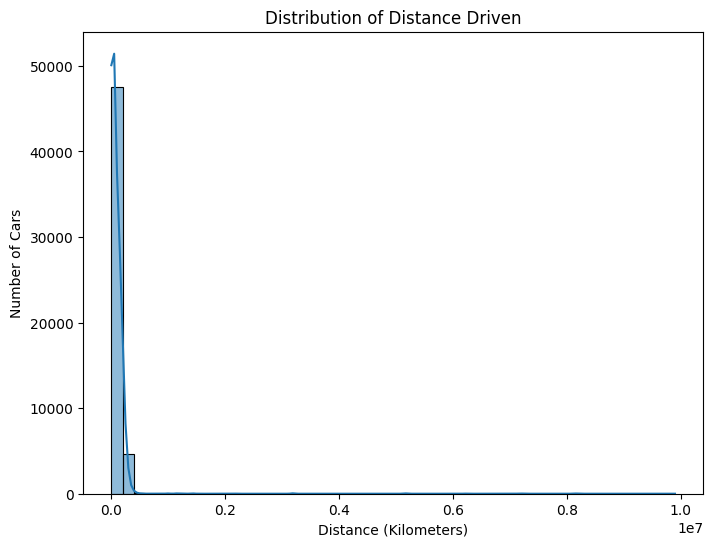

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(
    data=train_df,
    x='Distance',
    bins=50,
    kde=True
)
plt.title('Distribution of Distance Driven')
plt.xlabel('Distance (Kilometers)')
plt.ylabel('Number of Cars')
plt.show()

### Observation

The distance variable is not evenly distributed and shows a right-skewed
distribution. Most cars have comparatively lower mileage, while a small
number of cars have very high distance values.

**2. Distribution of Age of car**

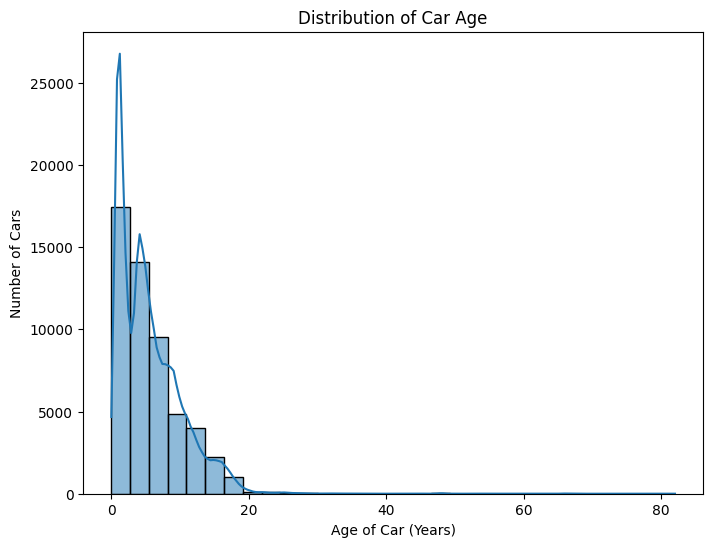

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(
    data=train_df,
    x='Age of car',
    bins=30,
    kde=True
)
plt.title('Distribution of Car Age')
plt.xlabel('Age of Car (Years)')
plt.ylabel('Number of Cars')
plt.show()

### Observation

Most vehicles belong to the relatively newer age groups, while a
smaller number of older vehicles are present in the dataset.

**3.Distribution of manufacture_year**

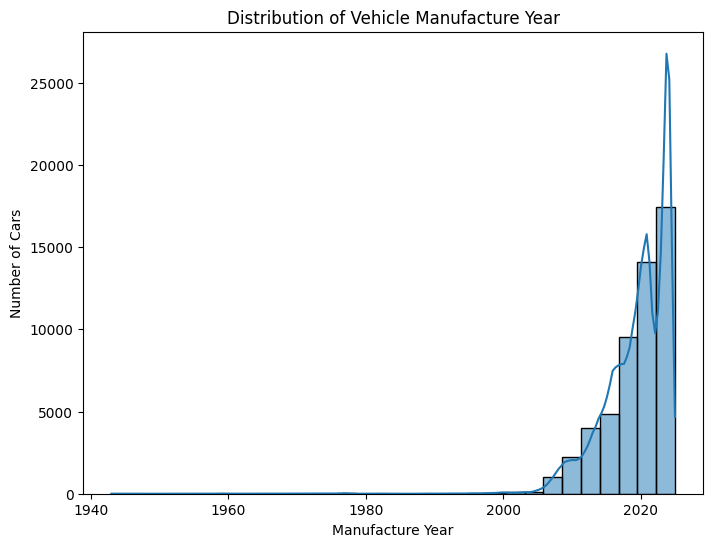

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(
    data=train_df,
    x='manufacture_year',
    bins=30,
    kde=True
)
plt.title('Distribution of Vehicle Manufacture Year')
plt.xlabel('Manufacture Year')
plt.ylabel('Number of Cars')
plt.show()

### Observation

The dataset contains vehicles manufactured across different years,
with a higher concentration of relatively newer vehicles.

**4. Distribution of engine_displacement**

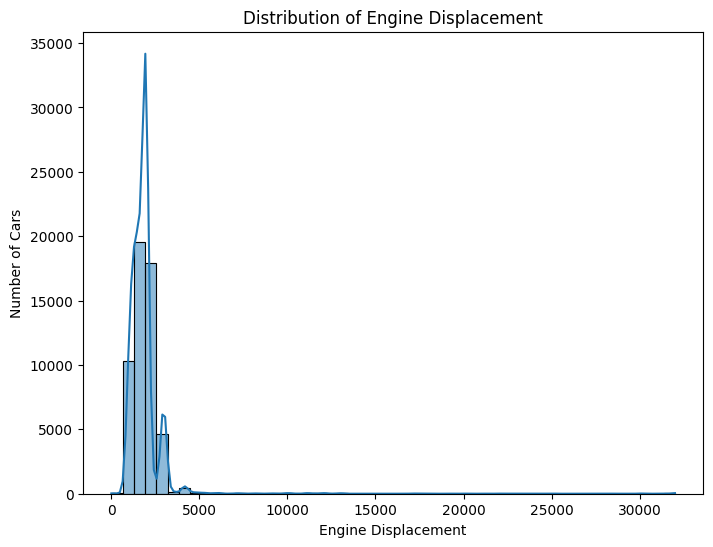

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(
    data=train_df,
    x='engine_displacement',
    bins=50,
    kde=True
)
plt.title('Distribution of Engine Displacement')
plt.xlabel('Engine Displacement')
plt.ylabel('Number of Cars')
plt.show()

### Observation

Engine displacement shows a concentrated distribution for most
vehicles, along with a small number of unusually high values.

**5. Distribution of engine_power**

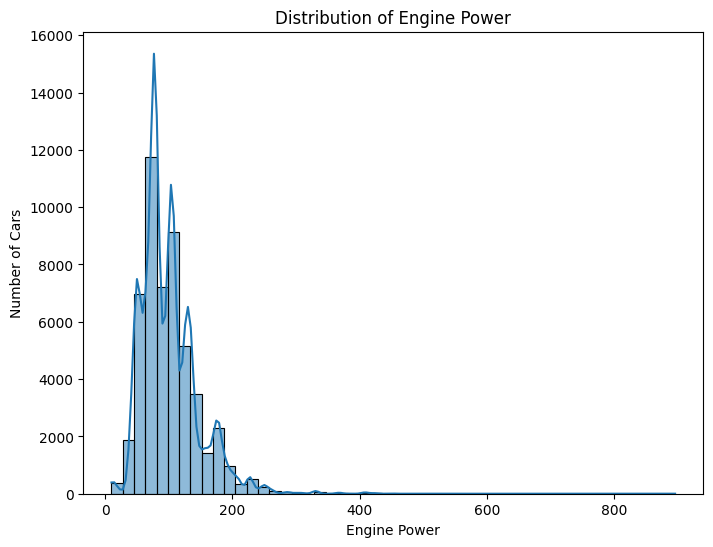

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(
    data=train_df,
    x='engine_power',
    bins=50,
    kde=True
)
plt.title('Distribution of Engine Power')
plt.xlabel('Engine Power')
plt.ylabel('Number of Cars')
plt.show()

### Observation

Engine power is concentrated within a certain range for most
vehicles, while some vehicles have considerably higher power values.

**6. Distribution of Vroom Audit Rating**

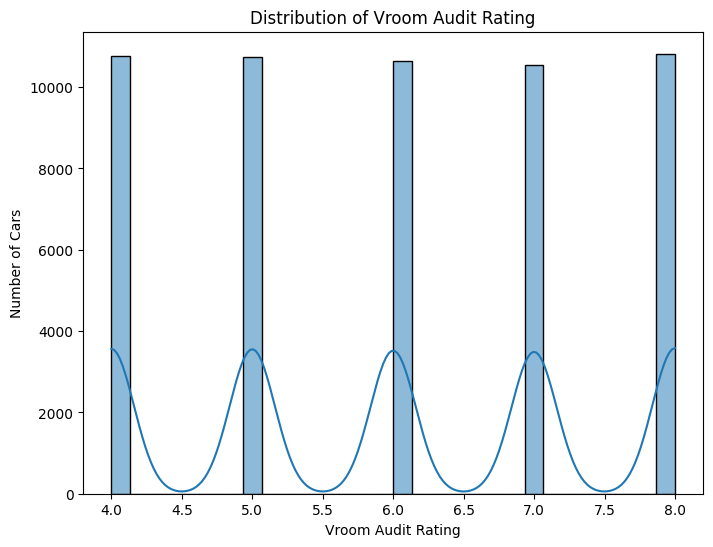

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(
    data=train_df,
    x='Vroom Audit Rating',
    bins=30,
    kde=True
)
plt.title('Distribution of Vroom Audit Rating')
plt.xlabel('Vroom Audit Rating')
plt.ylabel('Number of Cars')
plt.show()

### Observation

The Vroom Audit Rating shows the distribution of vehicle ratings
present in the dataset. The spread of ratings will be considered
while analyzing its relationship with vehicle price.

**7. Distribution of door_count**

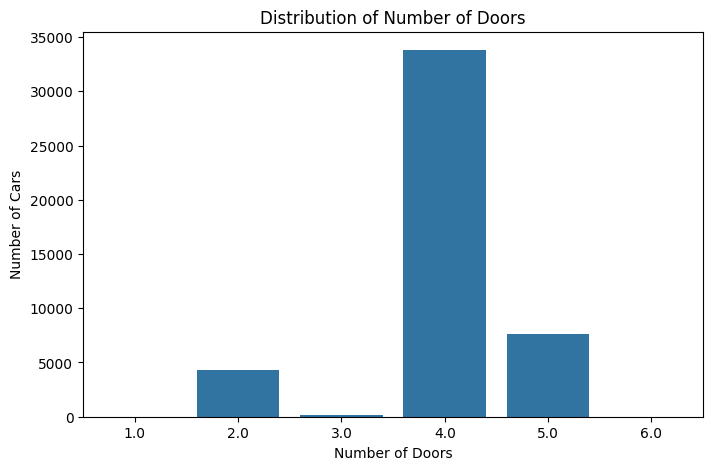

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=train_df,
    x='door_count'
)
plt.title('Distribution of Number of Doors')
plt.xlabel('Number of Doors')
plt.ylabel('Number of Cars')
plt.show()

### Observation

The dataset contains vehicles with different numbers of doors,
with some configurations occurring more frequently than others.

**8. Distribution of seat_count**

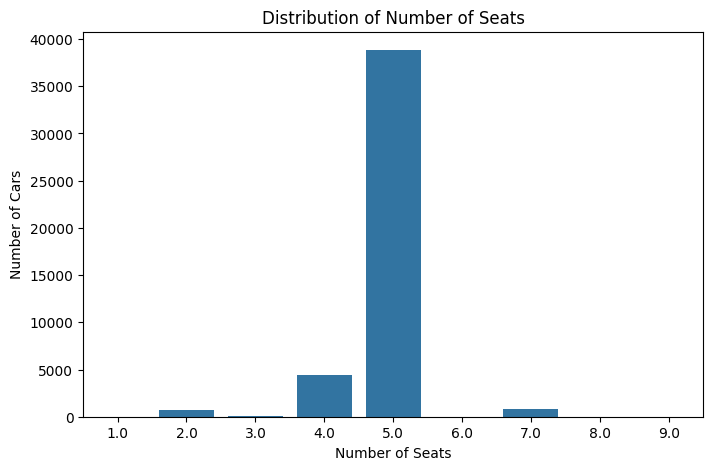

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=train_df,
    x='seat_count'
)
plt.title('Distribution of Number of Seats')
plt.xlabel('Number of Seats')
plt.ylabel('Number of Cars')
plt.show()

### Observation

The dataset contains vehicles with different seating capacities,
with certain seating configurations being more common than others.

**9. Target Variable — Price**

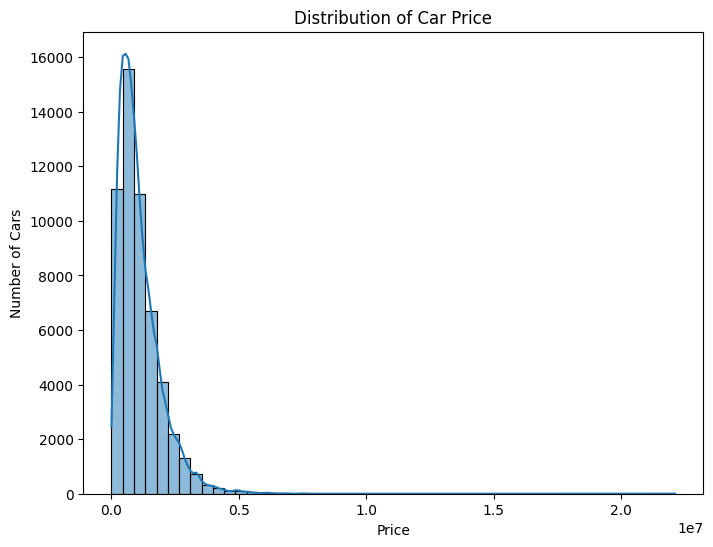

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(
    data=train_df,
    x='Price',
    bins=50,
    kde=True
)
plt.title('Distribution of Car Price')
plt.xlabel('Price')
plt.ylabel('Number of Cars')
plt.show()

### Observation

The price distribution is strongly right-skewed. Most vehicles are
concentrated within a lower price range, while a smaller number of
vehicles have considerably higher prices.

**10. Boxplot of Distance**


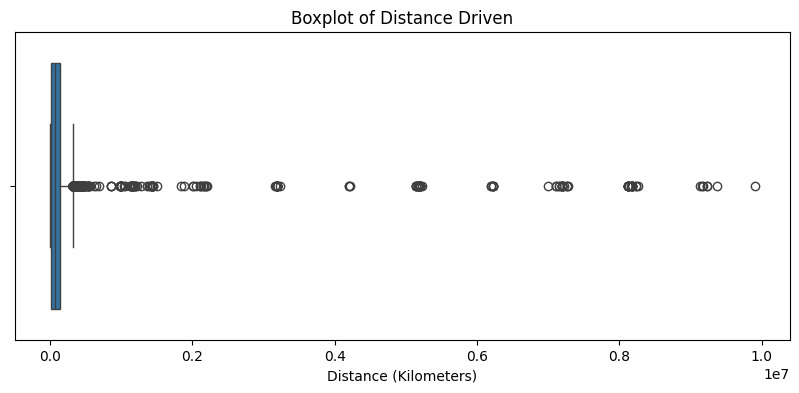

In [ ]:
plt.figure(figsize=(10, 4))
sns.boxplot(
    x=train_df['Distance']
)
plt.title('Boxplot of Distance Driven')
plt.xlabel('Distance (Kilometers)')
plt.show()

### Observation

The boxplot shows several observations beyond the upper range of
the distribution, indicating the presence of potential distance
outliers.

**11. Engine Power Boxplot**

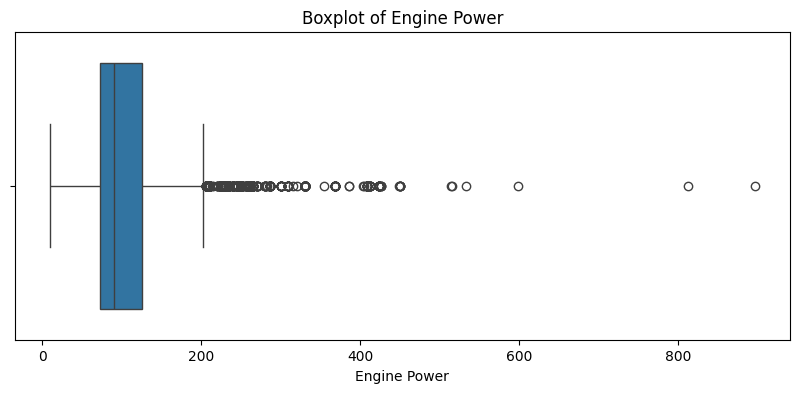

In [ ]:
plt.figure(figsize=(10, 4))
sns.boxplot(
    x=train_df['engine_power']
)
plt.title('Boxplot of Engine Power')
plt.xlabel('Engine Power')
plt.show()

### Observation

The boxplot indicates the presence of some high engine power values
outside the main distribution.

**12.Engine Displacement Boxplot**

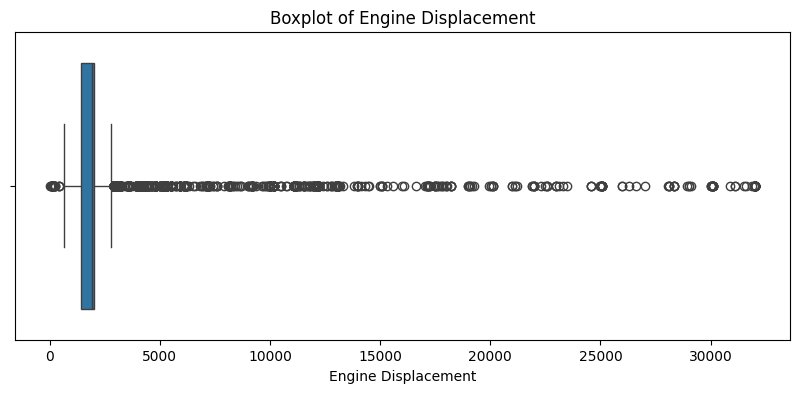

In [ ]:
plt.figure(figsize=(10, 4))
sns.boxplot(
    x=train_df['engine_displacement']
)
plt.title('Boxplot of Engine Displacement')
plt.xlabel('Engine Displacement')
plt.show()

### Observation

The distribution contains some unusually high engine displacement
values.

**13.Price Boxplot**

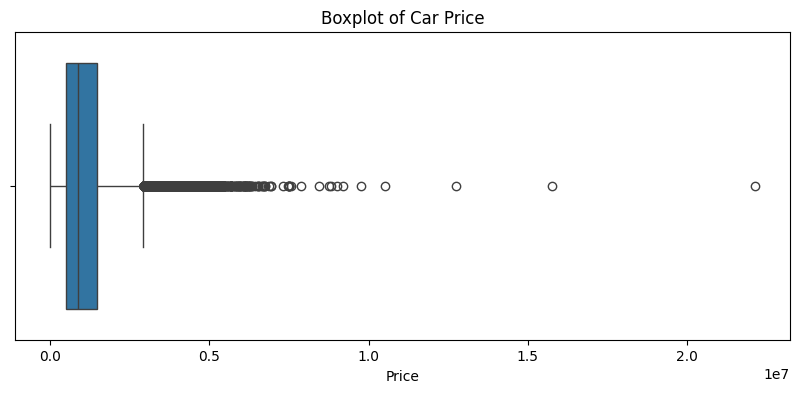

In [ ]:
plt.figure(figsize=(10, 4))
sns.boxplot(
    x=train_df['Price']
)
plt.title('Boxplot of Car Price')
plt.xlabel('Price')
plt.show()

### Observation

The price variable contains a number of high-value observations
outside the main distribution.

**14.Maker Distribution**

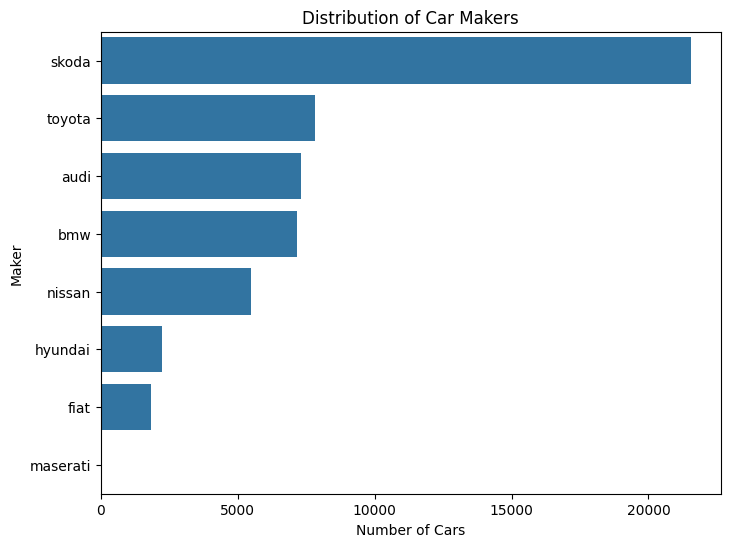

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(
    data=train_df,
    y='Maker',
    order=train_df['Maker'].value_counts().index
)
plt.title('Distribution of Car Makers')
plt.xlabel('Number of Cars')
plt.ylabel('Maker')
plt.show()

### Observation

The dataset contains vehicles from multiple manufacturers, with
some makers having a higher number of observations than others.

**15.Top 15 Model Distribution**

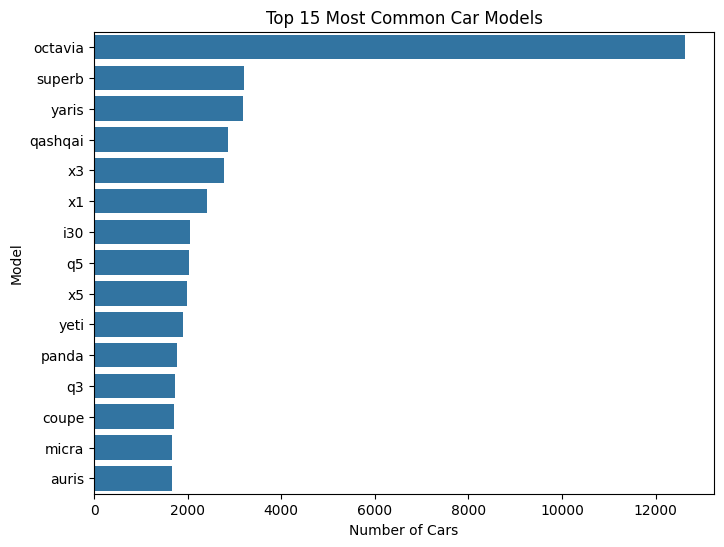

In [ ]:
top_models = train_df['model'].value_counts().head(15)
plt.figure(figsize=(8, 6))
sns.barplot(
    x=top_models.values,
    y=top_models.index
)
plt.title('Top 15 Most Common Car Models')
plt.xlabel('Number of Cars')
plt.ylabel('Model')
plt.show()

### Observation

The dataset contains several car models with different frequencies.
Some models are represented more frequently than others.

**16.Categorical Features vs Price**

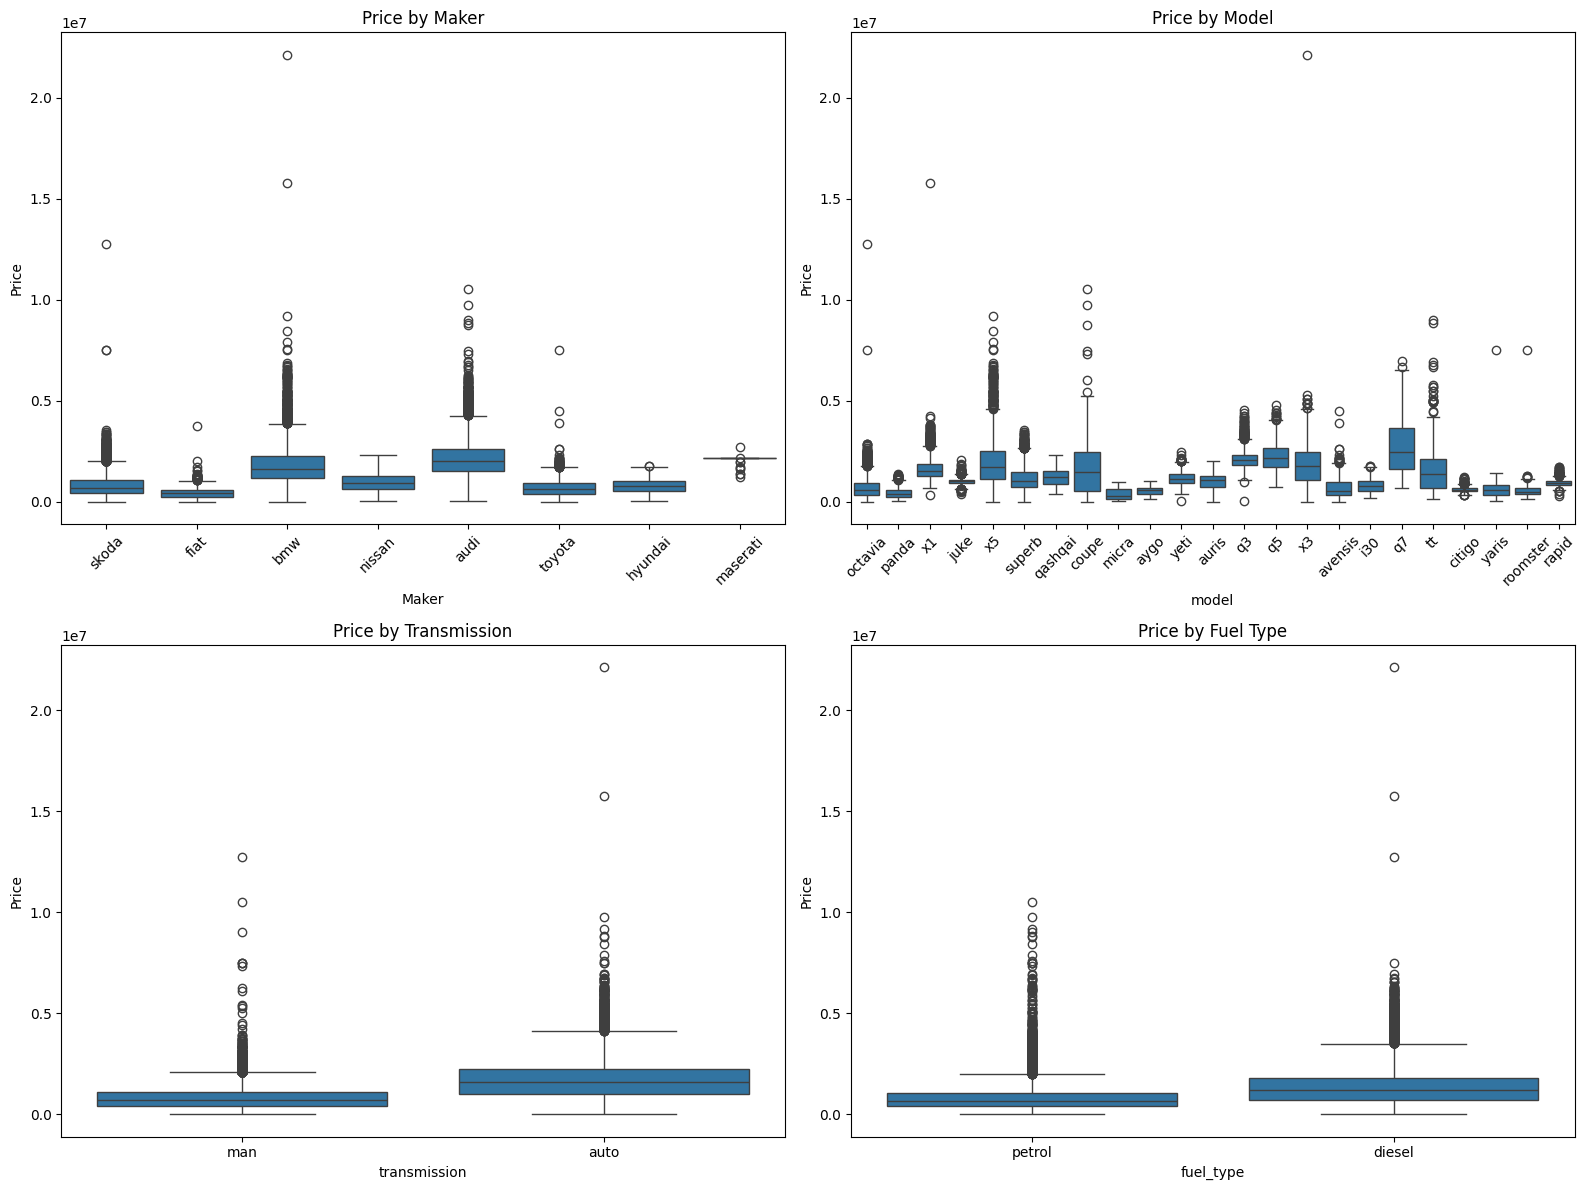

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Maker
sns.boxplot(
    data=train_df,
    x='Maker',
    y='Price',
    ax=axes[0, 0]
)
axes[0, 0].set_title('Price by Maker')
axes[0, 0].tick_params(axis='x', rotation=45)

# Model
sns.boxplot(
    data=train_df,
    x='model',
    y='Price',
    ax=axes[0, 1]
)
axes[0, 1].set_title('Price by Model')
axes[0, 1].tick_params(axis='x', rotation=45)

# Transmission
sns.boxplot(
    data=train_df,
    x='transmission',
    y='Price',
    ax=axes[1, 0]
)
axes[1, 0].set_title('Price by Transmission')

# Fuel Type
sns.boxplot(
    data=train_df,
    x='fuel_type',
    y='Price',
    ax=axes[1, 1]
)
axes[1, 1].set_title('Price by Fuel Type')
plt.tight_layout()
plt.show()

### Observation

The price distribution varies across makers, models, transmission
types and fuel types. These categorical features may therefore
provide useful information for predicting car price.

 # **Correlation Analysis**

Correlation analysis is performed to understand the relationship between
numerical features and the target variable, Price.
It helps identify features that may have a stronger relationship with
car prices and also highlights highly correlated features.

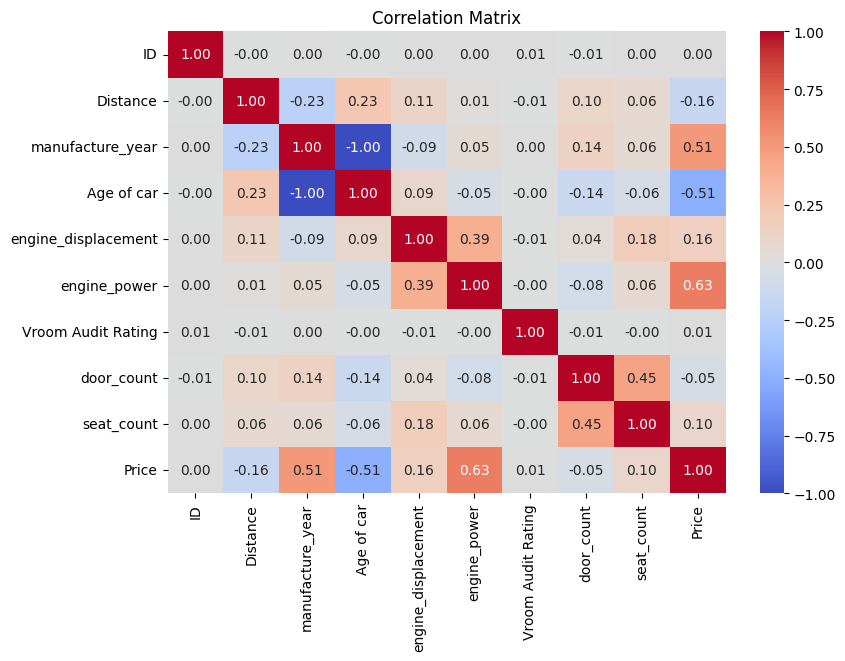

In [ ]:
# Correlation matrix for numerical features

correlation_matrix = train_df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(9, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Correlation Matrix')
plt.show()

In [ ]:
# Correlation with target variable

price_correlation = correlation_matrix['Price'].sort_values(ascending=False)
price_correlation

,Price
Price,1.000000
engine_power,0.627944
manufacture_year,0.506709
engine_displacement,0.162072
seat_count,0.098322
Vroom Audit Rating,0.005109
ID,0.003195
door_count,-0.053044
Distance,-0.158515
Age of car,-0.506703


### Observation

Engine power has the strongest positive correlation with Price, while
Age of car has a moderate negative correlation. Manufacture year also
shows a moderate positive relationship with Price.



# **Outlier Analysis**

Outlier analysis is performed to identify unusual values that may affect
model performance.

In [ ]:
# Check important numerical features for extreme values

outlier_columns = [
    'Distance',
    'engine_displacement',
    'engine_power',
    'Price'
]

for col in outlier_columns:
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((train_df[col] < lower) | (train_df[col] > upper)).sum()
    print(f"{col}: {outliers} outliers")

Distance: 548 outliers
engine_displacement: 5651 outliers
engine_power: 1406 outliers
Price: 1948 outliers


In [ ]:
# Data Cleaning

df = train_df.copy()                      # making a copy
print("Shape before cleaning:", df.shape)

Shape before cleaning: (53515, 17)


In [ ]:
df.columns = df.columns.str.strip()    # fix column names

In [ ]:
df.isnull().sum().sort_values(ascending=False)   # Check missing values

,0
body_type,49379
seat_count,8511
door_count,7534
engine_power,1439
Distance,1211
Location,6
manufacture_year,2
ID,0
model,0
engine_displacement,0


In [ ]:
df['body_type'] = df['body_type'].fillna('Unknown')

In [ ]:
# Checking impossible values

print("Manufacture year range:",
      df['manufacture_year'].min(),
      "to",
      df['manufacture_year'].max())

print("Age range:",
      df['Age of car'].min(),
      "to",
      df['Age of car'].max())

print("Distance range:",
      df['Distance'].min(),
      "to",
      df['Distance'].max())

print("Engine displacement range:",
      df['engine_displacement'].min(),
      "to",
      df['engine_displacement'].max())

print("Engine power range:",
      df['engine_power'].min(),
      "to",
      df['engine_power'].max())

print("Price range:",
      df['Price'].min(),
      "to",
      df['Price'].max())

Manufacture year range: 1943.0 to 2025.0
Age range: 0 to 82
Distance range: 0.0 to 9899800.0
Engine displacement range: 14 to 32000
Engine power range: 10.0 to 896.0
Price range: 3.0 to 22120775.25


# **Feature Engineering**

In [ ]:
# Remove ID from the dataset

df = df.drop(columns=['ID'])
print("Shape after removing ID:", df.shape)

Shape after removing ID: (53515, 16)


In [ ]:
# Check relationship between manufacture year and car age

df[['manufacture_year', 'Age of car']].head(10)

,manufacture_year,Age of car
0,1973.0,52
1,2021.0,4
2,2023.0,2
3,2020.0,5
4,2021.0,4
5,2024.0,1
6,2018.0,7
7,NaN,5
8,NaN,5
9,2019.0,6


In [ ]:
# Check whether manufacture year + car age is approximately 2025

(df['manufacture_year'] + df['Age of car']).value_counts().head(10)

,count
2025.0,53513


In [ ]:
# Remove redundant manufacture year

df = df.drop(columns=['manufacture_year'])
print("Shape after removing manufacture_year:", df.shape)

Shape after removing manufacture_year: (53515, 15)


In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
seat_count,8511
door_count,7534
engine_power,1439
Distance,1211
Location,6
model,0
Maker,0
engine_displacement,0
Age of car,0
Owner Type,0


In [ ]:
# Separate features and target

X = df.drop(columns=['Price'])
y = df['Price']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (53515, 14)
Target shape: (53515,)


In [ ]:
# split the data

from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("Training data:", X_train.shape)
print("Validation data:", X_val.shape)

Training data: (42812, 14)
Validation data: (10703, 14)


# **Preprocessing Pipeline**

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Numerical features
numeric_features = [
    'Distance',
    'Age of car',
    'engine_displacement',
    'engine_power',
    'door_count',
    'seat_count',
    'Vroom Audit Rating'
]

# Categorical features
categorical_features = [
    'Maker',
    'model',
    'Location',
    'Owner Type',
    'body_type',
    'transmission',
    'fuel_type'
]
print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

Numerical features: ['Distance', 'Age of car', 'engine_displacement', 'engine_power', 'door_count', 'seat_count', 'Vroom Audit Rating']
Categorical features: ['Maker', 'model', 'Location', 'Owner Type', 'body_type', 'transmission', 'fuel_type']


In [ ]:
# Numerical preprocessing
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [ ]:
# combine them

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

In [ ]:
print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['Distance', 'Age of car',
                                  'engine_displacement', 'engine_power',
                                  'door_count', 'seat_count',
                                  'Vroom Audit Rating']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Maker', 'model', 'Location', 'Owner Type',
                                  'body_type', 't

In [ ]:
# baseline model

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Predict the mean training price for every validation sample
baseline_prediction = np.full(
    len(y_val),
    y_train.mean()
)
baseline_rmse = np.sqrt(
    mean_squared_error(y_val, baseline_prediction)
)
baseline_mae = mean_absolute_error(
    y_val,
    baseline_prediction
)
baseline_r2 = r2_score(
    y_val,
    baseline_prediction
)
print("Baseline RMSE:", baseline_rmse)
print("Baseline MAE:", baseline_mae)
print("Baseline R²:", baseline_r2)

Baseline RMSE: 843683.7864072346
Baseline MAE: 627030.3041062129
Baseline R²: -0.00019259605421928505


# **Linear Regression**

In [ ]:
from sklearn.linear_model import LinearRegression

# Create complete pipeline
linear_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Train the model
linear_model.fit(X_train, y_train)

# Predict validation data
y_pred_linear = linear_model.predict(X_val)

# Evaluation
linear_rmse = np.sqrt(mean_squared_error(y_val, y_pred_linear))
linear_mae = mean_absolute_error(y_val, y_pred_linear)
linear_r2 = r2_score(y_val, y_pred_linear)

print("Linear Regression Results")
print("-------------------------")
print("RMSE:", linear_rmse)
print("MAE :", linear_mae)
print("R²  :", linear_r2)

Linear Regression Results
-------------------------
RMSE: 430074.2198472113
MAE : 262591.80359898874
R²  : 0.7400971453606169


In [ ]:
results = pd.DataFrame({
    'Model': ['Baseline', 'Linear Regression'],
    'RMSE': [baseline_rmse, linear_rmse],
    'MAE': [baseline_mae, linear_mae],
    'R2': [baseline_r2, linear_r2]
})
results

,Model,RMSE,MAE,R2
0,Baseline,843683.786407,627030.304106,-0.000193
1,Linear Regression,430074.219847,262591.803599,0.740097


### Observation

Linear Regression provides a basic machine learning benchmark.
Its performance will be compared with tree-based regression models,
which can capture non-linear relationships between vehicle features
and price.

# **Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest pipeline
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

# Train
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_val)

# Evaluation
rf_rmse = np.sqrt(mean_squared_error(y_val, y_pred_rf))
rf_mae = mean_absolute_error(y_val, y_pred_rf)
rf_r2 = r2_score(y_val, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print("RMSE:", rf_rmse)
print("MAE :", rf_mae)
print("R²  :", rf_r2)

Random Forest Results
---------------------
RMSE: 201476.21895448497
MAE : 107595.7377251826
R²  : 0.942961011789399


In [ ]:
results = pd.DataFrame({
    'Model': [
        'Baseline',
        'Linear Regression',
        'Random Forest'
    ],
    'RMSE': [
        baseline_rmse,
        linear_rmse,
        rf_rmse
    ],
    'MAE': [
        baseline_mae,
        linear_mae,
        rf_mae
    ],
    'R2': [
        baseline_r2,
        linear_r2,
        rf_r2
    ]
})
results

,Model,RMSE,MAE,R2
0,Baseline,843683.786407,627030.304106,-0.000193
1,Linear Regression,430074.219847,262591.803599,0.740097
2,Random Forest,201476.218954,107595.737725,0.942961


# **XGBoost**

In [ ]:
from xgboost import XGBRegressor

xgb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        objective='reg:squarederror'
    ))
])

# Train
xgb_model.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb_model.predict(X_val)

# Evaluation
xgb_rmse = np.sqrt(mean_squared_error(y_val, y_pred_xgb))
xgb_mae = mean_absolute_error(y_val, y_pred_xgb)
xgb_r2 = r2_score(y_val, y_pred_xgb)

print("XGBoost Results")
print("----------------")
print("RMSE:", xgb_rmse)
print("MAE :", xgb_mae)
print("R²  :", xgb_r2)

XGBoost Results
----------------
RMSE: 201181.22322476114
MAE : 108717.02650906872
R²  : 0.943127919226652


In [ ]:
results = pd.DataFrame({
    'Model': [
        'Baseline',
        'Linear Regression',
        'Random Forest',
        'XGBoost'
    ],
    'RMSE': [
        baseline_rmse,
        linear_rmse,
        rf_rmse,
        xgb_rmse
    ],
    'MAE': [
        baseline_mae,
        linear_mae,
        rf_mae,
        xgb_mae
    ],
    'R2': [
        baseline_r2,
        linear_r2,
        rf_r2,
        xgb_r2
    ]
})

results.sort_values('RMSE')

,Model,RMSE,MAE,R2
3,XGBoost,201181.223225,108717.026509,0.943128
2,Random Forest,201476.218954,107595.737725,0.942961
1,Linear Regression,430074.219847,262591.803599,0.740097
0,Baseline,843683.786407,627030.304106,-0.000193


## **Cross-Validation**

Five-fold cross-validation is used to evaluate the stability and
generalization performance of the regression models.
The training data is divided into five folds. Each fold is used once
as validation data while the remaining folds are used for training.

RMSE, MAE and R² are calculated across the five folds.

In [ ]:
from sklearn.model_selection import KFold, cross_validate

# 5-fold cross-validation
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
scoring = {
    'RMSE': 'neg_root_mean_squared_error',
    'MAE': 'neg_mean_absolute_error',
    'R2': 'r2'
}

In [ ]:
# Cross validate RandomForest

rf_cv = cross_validate(
    rf_model,
    X,
    y,
    cv=kf,
    scoring=scoring,
    n_jobs=-1
)

rf_cv_rmse = -rf_cv['test_RMSE']
rf_cv_mae = -rf_cv['test_MAE']
rf_cv_r2 = rf_cv['test_R2']

print("Random Forest - 5 Fold CV")
print("-------------------------")
print("Mean RMSE:", rf_cv_rmse.mean())
print("Mean MAE :", rf_cv_mae.mean())
print("Mean R²  :", rf_cv_r2.mean())

Random Forest - 5 Fold CV
-------------------------
Mean RMSE: 231525.22073024535
Mean MAE : 107663.45674941517
Mean R²  : 0.9234793492455864


In [ ]:
#Cross validate XGBoost
xgb_cv = cross_validate(
    xgb_model,
    X,
    y,
    cv=kf,
    scoring=scoring,
    n_jobs=-1
)

xgb_cv_rmse = -xgb_cv['test_RMSE']
xgb_cv_mae = -xgb_cv['test_MAE']
xgb_cv_r2 = xgb_cv['test_R2']

print("XGBoost - 5 Fold CV")
print("--------------------")
print("Mean RMSE:", xgb_cv_rmse.mean())
print("Mean MAE :", xgb_cv_mae.mean())
print("Mean R²  :", xgb_cv_r2.mean())

XGBoost - 5 Fold CV
--------------------
Mean RMSE: 224774.43911925663
Mean MAE : 108144.36133443895
Mean R²  : 0.9277944865555744


In [ ]:
#Comparing both
cv_results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Mean RMSE': [
        rf_cv_rmse.mean(),
        xgb_cv_rmse.mean()
    ],
    'Mean MAE': [
        rf_cv_mae.mean(),
        xgb_cv_mae.mean()
    ],
    'Mean R2': [
        rf_cv_r2.mean(),
        xgb_cv_r2.mean()
    ]
})

cv_results.sort_values('Mean RMSE')

,Model,Mean RMSE,Mean MAE,Mean R2
1,XGBoost,224774.439119,108144.361334,0.927794
0,Random Forest,231525.220730,107663.456749,0.923479


## **Hyperparameter Tuning**

Hyperparameter tuning is performed to improve the performance of the
XGBoost regression model.

RandomizedSearchCV is used with five-fold cross-validation to search
for a better combination of model hyperparameters.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Hyperparameter search space
param_grid = {
    'model__n_estimators': [200, 300, 400, 500],
    'model__max_depth': [4, 6, 8, 10],
    'model__learning_rate': [0.03, 0.05, 0.08, 0.1],
    'model__subsample': [0.7, 0.8, 0.9, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

xgb_tuning = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    n_iter=10,
    scoring='neg_root_mean_squared_error',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Run tuning
xgb_tuning.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median'))]),
                                                                               ['Distance',
                                                                                'Age '
                                                                                'of '
                                                                                'car',
                                                                                'engine_displacement',
                                                                                'engine_power',
                                                                                'door_count',
                                                                                'seat_count',
                                                                                'Vroom '
                                                                                'Audit '
                                                                                'Rating']),
                                                                              ('cat',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_freq...
                                                           multi_strategy=None,
                                                           n_estimators=300,
                                                           n_jobs=-1,
                                                           num_parallel_tree=None, ...))]),
                   n_jobs=-1,
                   param_distributions={'model__colsample_bytree': [0.7, 0.8,
                                                                    0.9, 1.0],
                                        'model__learning_rate': [0.03, 0.05,
                                                                 0.08, 0.1],
                                        'model__max_depth': [4, 6, 8, 10],
                                        'model__n_estimators': [200, 300, 400,
                                                                500],
                                        'model__subsample': [0.7, 0.8, 0.9,
                                                             1.0]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=1)

In [ ]:
print("Best Parameters:")
print(xgb_tuning.best_params_)

print("\nBest CV RMSE:")
print(-xgb_tuning.best_score_)

Best Parameters:
{'model__subsample': 0.7, 'model__n_estimators': 300, 'model__max_depth': 6, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.7}

Best CV RMSE:
231066.32234459734


In [ ]:
#Evaluate tuned model on validation data
best_xgb = xgb_tuning.best_estimator_

y_pred_tuned = best_xgb.predict(X_val)

tuned_rmse = np.sqrt(
    mean_squared_error(y_val, y_pred_tuned)
)

tuned_mae = mean_absolute_error(
    y_val,
    y_pred_tuned
)

tuned_r2 = r2_score(
    y_val,
    y_pred_tuned
)

print("Tuned XGBoost Results")
print("---------------------")
print("RMSE:", tuned_rmse)
print("MAE :", tuned_mae)
print("R²  :", tuned_r2)

Tuned XGBoost Results
---------------------
RMSE: 200043.78572939616
MAE : 116581.84329415526
R²  : 0.9437691875167996


In [ ]:
results = pd.DataFrame({
    'Model': [
        'Baseline',
        'Linear Regression',
        'Random Forest',
        'XGBoost',
        'Tuned XGBoost'
    ],
    'RMSE': [
        baseline_rmse,
        linear_rmse,
        rf_rmse,
        xgb_rmse,
        tuned_rmse
    ],
    'MAE': [
        baseline_mae,
        linear_mae,
        rf_mae,
        xgb_mae,
        tuned_mae
    ],
    'R2': [
        baseline_r2,
        linear_r2,
        rf_r2,
        xgb_r2,
        tuned_r2
    ]
})

results.sort_values('RMSE')

,Model,RMSE,MAE,R2
4,Tuned XGBoost,200043.785729,116581.843294,0.943769
3,XGBoost,201181.223225,108717.026509,0.943128
2,Random Forest,201476.218954,107595.737725,0.942961
1,Linear Regression,430074.219847,262591.803599,0.740097
0,Baseline,843683.786407,627030.304106,-0.000193


In [ ]:
# Select the best model based on validation RMSE
final_model = best_xgb

print("Selected Final Model: Tuned XGBoost")
print("Validation RMSE:", tuned_rmse)
print("Validation MAE :", tuned_mae)
print("Validation R²  :", tuned_r2)

Selected Final Model: Tuned XGBoost
Validation RMSE: 200043.78572939616
Validation MAE : 116581.84329415526
Validation R²  : 0.9437691875167996


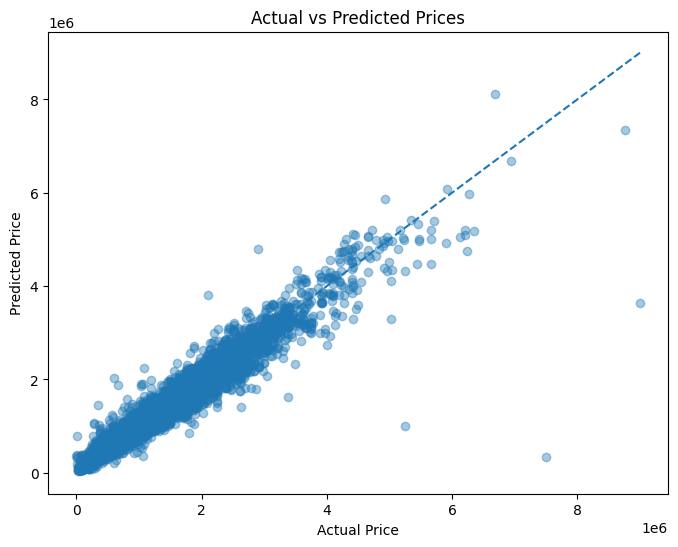

In [ ]:
# ACtual vs Predicted
plt.figure(figsize=(8, 6))

plt.scatter(
    y_val,
    y_pred_tuned,
    alpha=0.4
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")

# Perfect prediction reference line
min_price = min(y_val.min(), y_pred_tuned.min())
max_price = max(y_val.max(), y_pred_tuned.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle='--'
)

plt.show()

### Observation

Most predicted values are distributed around the reference line,
indicating that the model is able to predict vehicle prices reasonably
well. Larger deviations are observed for some high-priced vehicles.

**Residual Analysis**

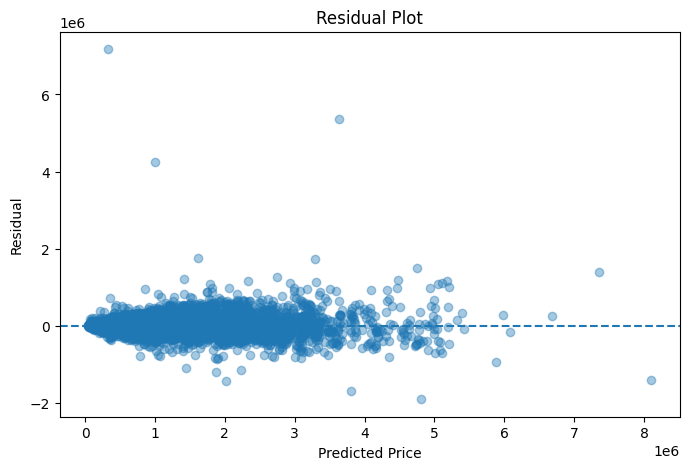

In [ ]:
# Residual analysis is performed to understand the prediction errors produced by the final model.
residuals = y_val - y_pred_tuned
plt.figure(figsize=(8, 5))
plt.scatter(
    y_pred_tuned,
    residuals,
    alpha=0.4
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

## Feature Importance

Feature importance is analyzed using the selected XGBoost model to
identify the features that contribute most to price prediction.

In [ ]:
# Get the fitted preprocessing step
fitted_preprocessor = best_xgb.named_steps['preprocessor']

# Get transformed feature names
feature_names = fitted_preprocessor.get_feature_names_out()

# Get XGBoost feature importance
importance_values = best_xgb.named_steps['model'].feature_importances_

# Create feature importance dataframe
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_values
})

# Top 20 features
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
).head(20)

feature_importance

,Feature,Importance
56,cat__transmission_auto,0.105577
3,num__engine_power,0.099941
1,num__Age of car,0.088609
13,cat__Maker_skoda,0.077998
7,cat__Maker_audi,0.077919
2,num__engine_displacement,0.056763
57,cat__transmission_man,0.050981
8,cat__Maker_bmw,0.038487
28,cat__model_qashqai,0.033136
25,cat__model_q3,0.032299


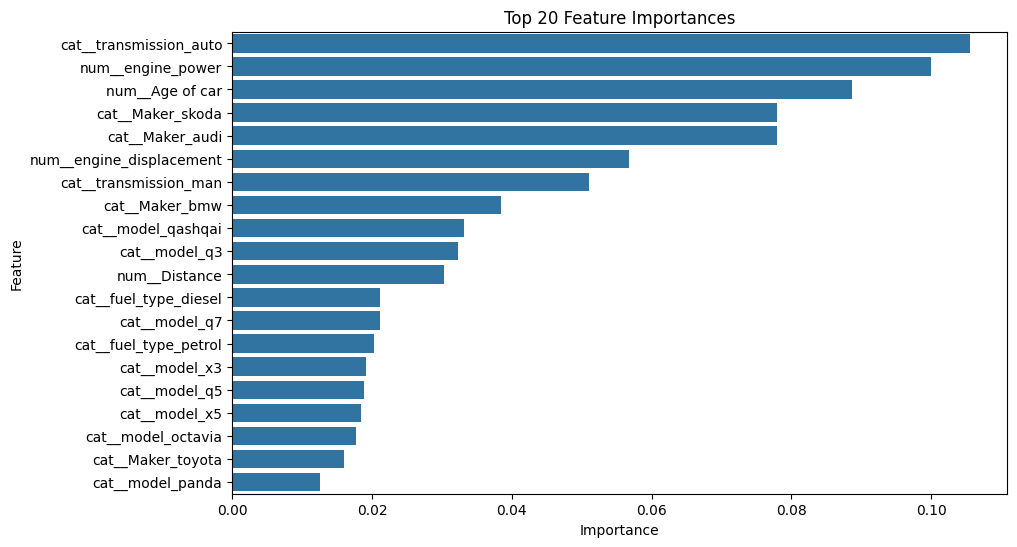

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title('Top 20 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

### Observation

The feature importance analysis shows that transmission type, engine
power, Age of car, vehicle maker and engine displacement are among the
most important features used by the XGBoost model for predicting car
prices.

In [ ]:
# Train the selected tuned model on all available training data

final_model.fit(X, y)
print("Final model trained successfully.")
print("Training samples used:", len(X))

Final model trained successfully.
Training samples used: 53515


 ## Test Data Prediction

The unseen test dataset is loaded after finalizing and training the
selected model.

The test dataset does not contain the target variable, Price. The final
model will be used to predict the price for each test observation.

In [ ]:
# Load test dataset
test_df = pd.read_csv("Cap_Test_Data_2025.csv")

# Clean column names
test_df.columns = test_df.columns.str.strip()

print("Test dataset shape:", test_df.shape)
test_df.head()

Test dataset shape: (5615, 16)


,ID,Maker,model,Location,Distance,Owner Type,manufacture_year,Age of car,engine_displacement,engine_power,body_type,Vroom Audit Rating,transmission,door_count,seat_count,fuel_type
0,21100001,skoda,octavia,Mumbai,150000.0,First,2016,9,1595,75.0,NaN,5,man,4.0,5.0,petrol
1,21100002,skoda,rapid,Coimbatore,29376.0,Third,2023,2,1598,77.0,NaN,4,man,4.0,5.0,diesel
2,21100003,skoda,octavia,Coimbatore,30563.0,Second,2023,2,1968,110.0,NaN,5,man,5.0,5.0,diesel
3,21100004,audi,q3,Delhi,8650.0,Fourth & Above,2024,1,1968,110.0,NaN,8,auto,4.0,5.0,diesel
4,21100005,audi,tt,Chennai,6400.0,Third,2024,1,1984,169.0,NaN,4,auto,2.0,NaN,petrol


In [ ]:
# we removed ID and manufacture_year from training, so we need to make the same feature changes to test data.

test_ids = test_df['ID']

# Remove columns not used by the model
X_test = test_df.drop(
    columns=['ID', 'manufacture_year']
)

# Handling body_type consistently with training data
X_test['body_type'] = X_test['body_type'].fillna('Unknown')

print("Test features shape:", X_test.shape)

Test features shape: (5615, 14)


In [ ]:
# Generate predictions
test_predictions = final_model.predict(X_test)

print("Number of predictions:", len(test_predictions))
print("First 10 predictions:")
print(test_predictions[:10])

Number of predictions: 5615
First 10 predictions:
[ 381053.88 1030675.4  1508388.   2448481.   2910028.2  2646008.8
 3258095.2  2453188.2   368438.38 1214487.1 ]


In [ ]:
submission = pd.DataFrame({
    'ID': test_ids,
    'Price': test_predictions
})

print("Submission shape:", submission.shape)
submission.head(10)

Submission shape: (5615, 2)


,ID,Price
0,21100001,381053.875
1,21100002,1030675.375
2,21100003,1508388.000
3,21100004,2448481.000
4,21100005,2910028.250
5,21100006,2646008.750
6,21100007,3258095.250
7,21100008,2453188.250
8,21100009,368438.375
9,21100010,1214487.125


In [ ]:
submission.to_csv(
    'predictions.csv',
    index=False
)
print("predictions.csv created successfully.")

predictions.csv created successfully.


In [ ]:
print(submission.shape)
print(submission.columns.tolist())
print(submission.isnull().sum())

(5615, 2)
['ID', 'Price']
ID       0
Price    0
dtype: int64


In [ ]:
import joblib

# Save the complete model pipeline
joblib.dump(
    final_model,
    'final_model.joblib'
)

print("final_model.joblib saved successfully.")

final_model.joblib saved successfully.


#  **Conclusion**

The Indian Pre-Owned Car Price Prediction project was developed using
a complete machine learning workflow.

The dataset was explored and cleaned, missing values were handled using
a preprocessing pipeline, categorical variables were encoded using
One-Hot Encoding, and relevant features were prepared for modelling.

Baseline, Linear Regression, Random Forest and XGBoost models were
evaluated using RMSE, MAE and R². Five-fold cross-validation and
hyperparameter tuning were performed to improve model performance.

The tuned XGBoost model was selected as the final model based on its
validation performance.

The final model was trained using the complete training dataset and
used to predict prices for the unseen test dataset. The predictions
were saved in the required ID and Price format.
The trained model was also saved as a Joblib file so that it can be
integrated into the Streamlit application for real-time predictions.